# Hackathon Task 3: Predictive Grid Management for Heat Pump Networks
## Exploratory Data Analysis and Time Series Analysis
This notebook provides a starting point for exploring the 10.4 GB `data.csv` dataset along with `devices.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import gc
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

## 1. Load Devices Metadata
`devices.csv` contains geographic coordinates for each device, which can be useful for clustering and linking external weather data.

In [2]:
devices_df = pd.read_csv('../data/devices.csv')
print(f"Total devices: {devices_df.shape[0]}")
display(devices_df.head())

Total devices: 600


,latitude,longitude,deviceId
0,50.0,18.3,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...
1,53.5,21.1,005767201ec5d7c3336b3b4d1ffa8a72e7ca1ecdaac30f...
2,52.9,18.1,01668c64ccc16c506a7c1a5c032e2eb5e2de48ecb284f2...
3,52.5,17.7,01bf745bf2df0312bd5ff2234c0e9dedc39ad0bac9bcfc...
4,50.7,16.7,02e4ad5d8d0016d35a003ea6df7e10fe27093aba81c64a...


### Plot Devices on the Map
Visualizing devices in Poland. We can see regional coverage corresponding to Enea, Energa, PGE, and Tauron areas.

In [3]:
# Plotting devices distribution (latitude & longitude) using Plotly
fig = px.scatter_mapbox(devices_df, lat="latitude", lon="longitude", 
                        hover_name="deviceId", zoom=4, height=500,
                        title="Device Geographic Distribution")
fig.update_layout(mapbox_style="open-street-map")
fig.show()

## 2. Load Telemetry Data (Subsampling)
Since `data.csv` is ~10.4GB, loading it entirely in a standard RAM environment or Jupyter notebook is not recommended.
We will load a chunk of data for EDA, e.g., using 1 million rows.

In [4]:
file_path = '../data/data.csv'

# Load only the first 1 million rows for initial EDA
df_sample = pd.read_csv(file_path, nrows=1000000)

print(f"Sample Data Shape: {df_sample.shape}")

# Convert timedate to pandas datetime objects
df_sample['timedate'] = pd.to_datetime(df_sample['timedate'])

display(df_sample.head())

Sample Data Shape: (1000000, 20)


,deviceId,timedate,period,t1,t2,t3,t4,t5,t6,t7,t8,t9,t10,t11,t12,t13,x1,x2,x3,deviceType
0,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2024-10-01 00:00:00+00:00,train,0.29,0.05,0.0,0.43,0.47,0.45,0.2,0.51,0.42,0.21,0.21,0.07,0.07,0.0,0.0,8,19
1,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2024-10-01 00:05:00+00:00,train,0.29,0.05,0.0,0.39,0.46,0.45,0.2,0.51,0.41,0.21,0.21,0.07,0.07,0.0,0.0,8,19
2,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2024-10-01 00:10:00+00:00,train,0.29,0.05,0.0,0.38,0.46,0.45,0.2,0.50,0.41,0.21,0.21,0.07,0.07,0.0,0.0,8,19
3,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2024-10-01 00:15:00+00:00,train,0.29,0.05,0.0,0.38,0.45,0.45,0.2,0.50,0.40,0.21,0.21,0.07,0.07,0.0,0.0,8,19
4,000cc3cb7f030c3d0c481bd0e7cf42ee283012c3cb5bfc...,2024-10-01 00:20:00+00:00,train,0.29,0.05,0.0,0.37,0.45,0.45,0.2,0.50,0.40,0.21,0.21,0.07,0.07,0.0,0.0,8,19


### Better Sampling: Extract all data for a few specific devices
Time series analysis requires continuous readings over time. Instead of random chunking, we can stream the CSV and extract everything for specific 3 `deviceId`s.

In [5]:
# Pick 3 devices from our metadata randomly
sample_devices = devices_df['deviceId'].sample(3, random_state=42).tolist()

print(f"Selected devices for time series analysis: \n{sample_devices}")

# Read chunk by chunk and filter (it takes a minute to scan the 10GB file)
chunks = []
chunksize = 2_000_000
for chunk in pd.read_csv('../data/data.csv', chunksize=chunksize):
    filtered_chunk = chunk[chunk['deviceId'].isin(sample_devices)]
    chunks.append(filtered_chunk)
    
df_ts = pd.concat(chunks, ignore_index=True)
df_ts['timedate'] = pd.to_datetime(df_ts['timedate'])
df_ts.sort_values(by=['deviceId', 'timedate'], inplace=True)

print(f"\nData strictly for the selected {len(sample_devices)} devices: {df_ts.shape}")
del chunks
gc.collect()

Selected devices for time series analysis: 
['32ce77f250bae7a0f8dbe78f95730f9ae7efa2aabd7882402e2158bd08fbf70c', 'b097fadf1169c39654071b15699257e9d12ac5d92dd8640e52f71e0cd99f8e1d', 'eead1e44092013764cd087dba330ef6110f2f552e4f18c0e6ecdc012ee5e4f2d']

Data strictly for the selected 3 devices: (329161, 20)


20

## 3. General Exploratory Data Analysis (EDA)
Looking at missing values, distributions and correlations between temperatures.

In [6]:
# Check missing values
display(df_sample.isna().sum() / len(df_sample) * 100)

deviceId       0.0000
timedate       0.0000
period         0.0000
t1             0.0000
t2             0.0000
t3             0.0000
t4             0.0000
t5             0.0000
t6             0.0000
t7             0.0000
t8             0.0000
t9             0.0000
t10            0.0000
t11            0.0000
t12            0.0000
t13            0.0000
x1             0.0000
x2            46.7431
x3             0.0000
deviceType     0.0000
dtype: float64

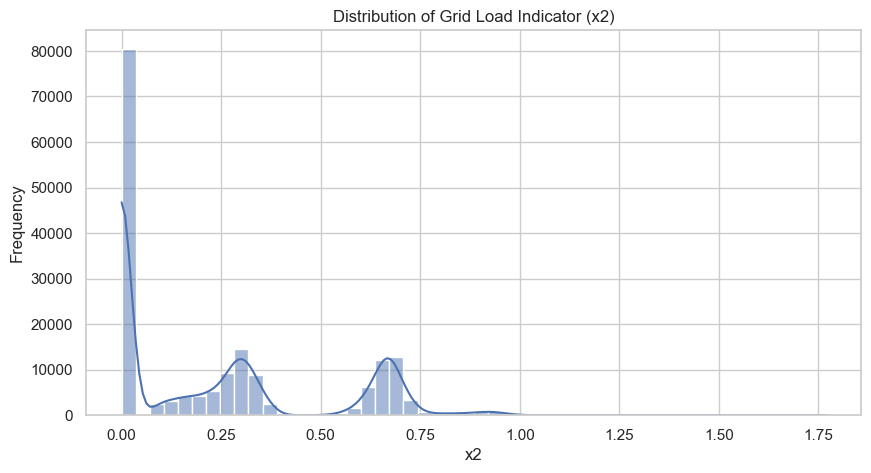

In [7]:
# Distribution of the target variable `x2` (Grid load indicator)
plt.figure(figsize=(10, 5))
sns.histplot(df_ts['x2'], bins=50, kde=True)
plt.title('Distribution of Grid Load Indicator (x2)')
plt.xlabel('x2')
plt.ylabel('Frequency')
plt.show()

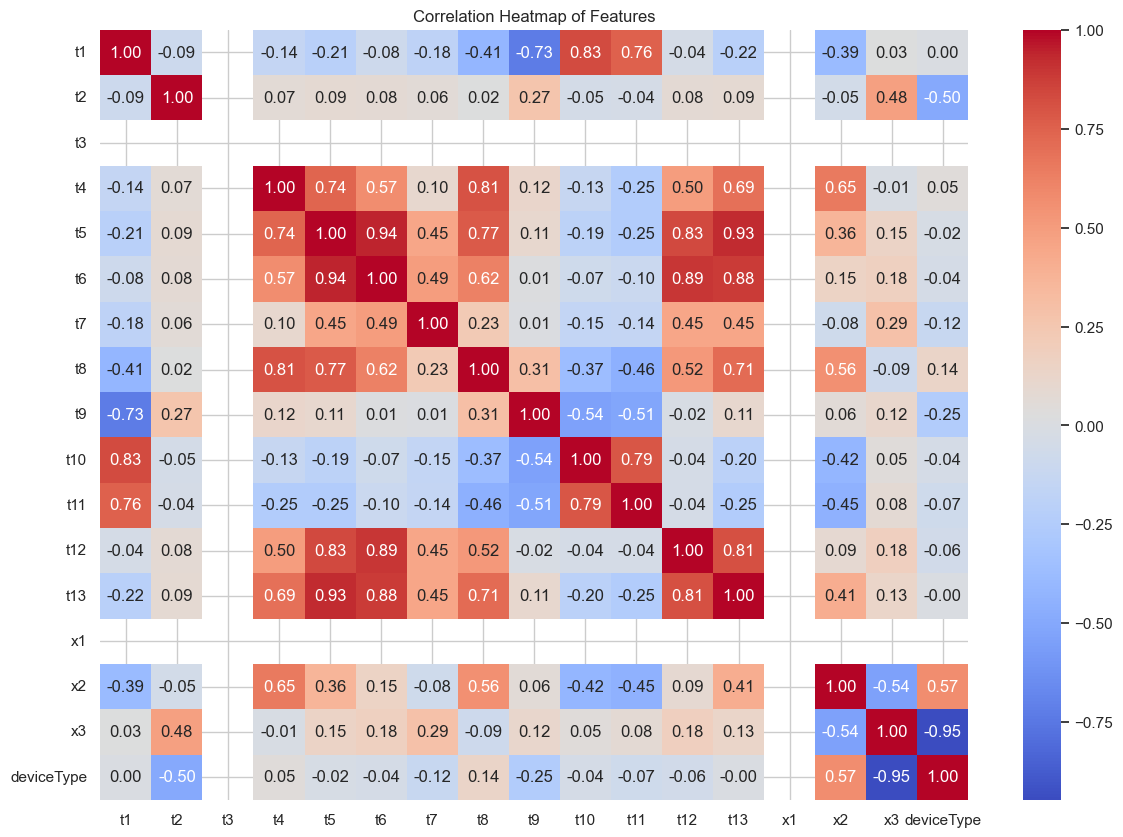

In [8]:
# Correlation matrix
numeric_cols = df_ts.select_dtypes(include=[np.number]).columns
corr = df_ts[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar=True)
plt.title("Correlation Heatmap of Features")
plt.show()

## 4. Time Series Analysis
Let's focus on one specific device to analyze daily, weekly, or seasonal load variation across time.

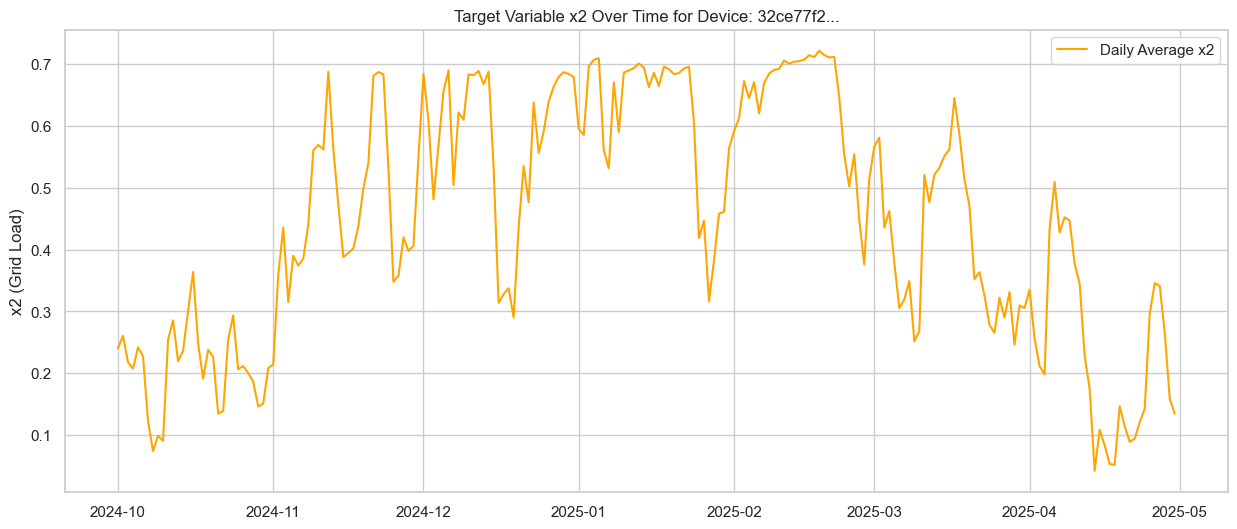

In [9]:
dev1_id = sample_devices[0]
dev1 = df_ts[df_ts['deviceId'] == dev1_id].set_index('timedate')

# Resample 5-minute data to Hourly (H) or Daily (D) using mean for visualization
dev1_hr = dev1.resample('H').mean(numeric_only=True)
dev1_daily = dev1.resample('D').mean(numeric_only=True)

plt.figure(figsize=(15, 6))
plt.plot(dev1_daily.index, dev1_daily['x2'], label='Daily Average x2', color='orange')
plt.title(f'Target Variable x2 Over Time for Device: {dev1_id[:8]}...')
plt.ylabel('x2 (Grid Load)')
plt.legend()
plt.show()

### External Temperature (`t1`) vs Grid Load (`x2`)
Grid load is directly correlated to the outdoor temperature. As temperature drops, heating requirements soar.

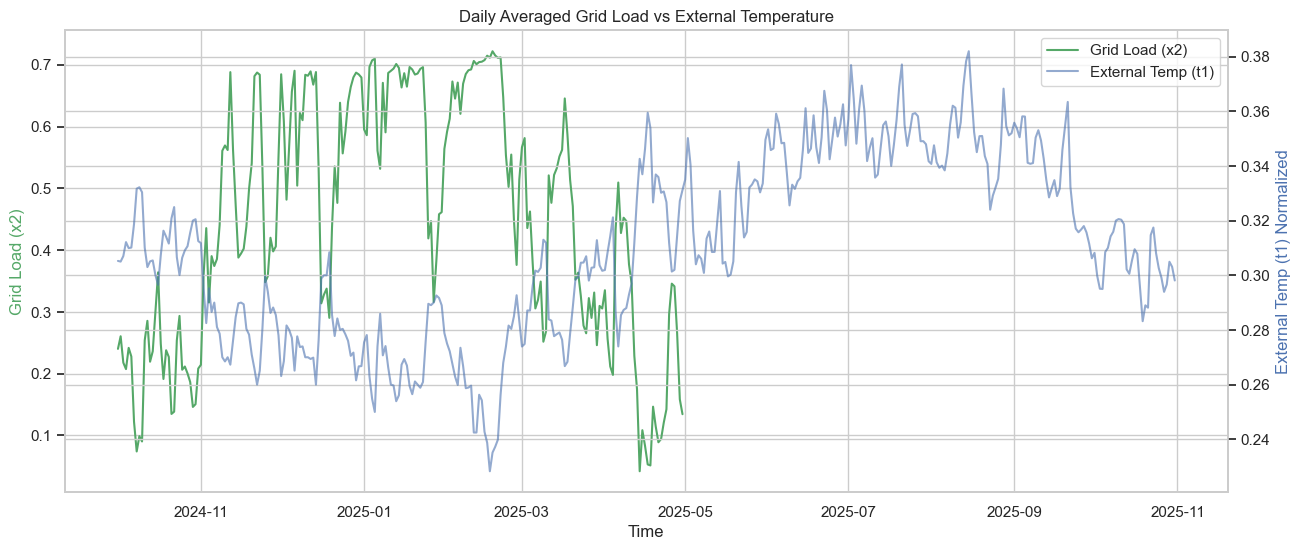

In [10]:
fig, ax1 = plt.subplots(figsize=(15, 6))

ax2 = ax1.twinx()
ax1.plot(dev1_daily.index, dev1_daily['x2'], 'g-', label='Grid Load (x2)')
ax2.plot(dev1_daily.index, dev1_daily['t1'], 'b-', label='External Temp (t1)', alpha=0.6)

ax1.set_xlabel('Time')
ax1.set_ylabel('Grid Load (x2)', color='g')
ax2.set_ylabel('External Temp (t1) Normalized', color='b')
plt.title('Daily Averaged Grid Load vs External Temperature')
fig.legend(loc="upper right", bbox_to_anchor=(0.9, 0.88))
plt.show()

### Autocorrelation (Seasonalities)
Data has a 5-minute interval: 
- 1 Hour = 12 steps
- 1 Day = 288 steps
Checking for daily recurring patterns.

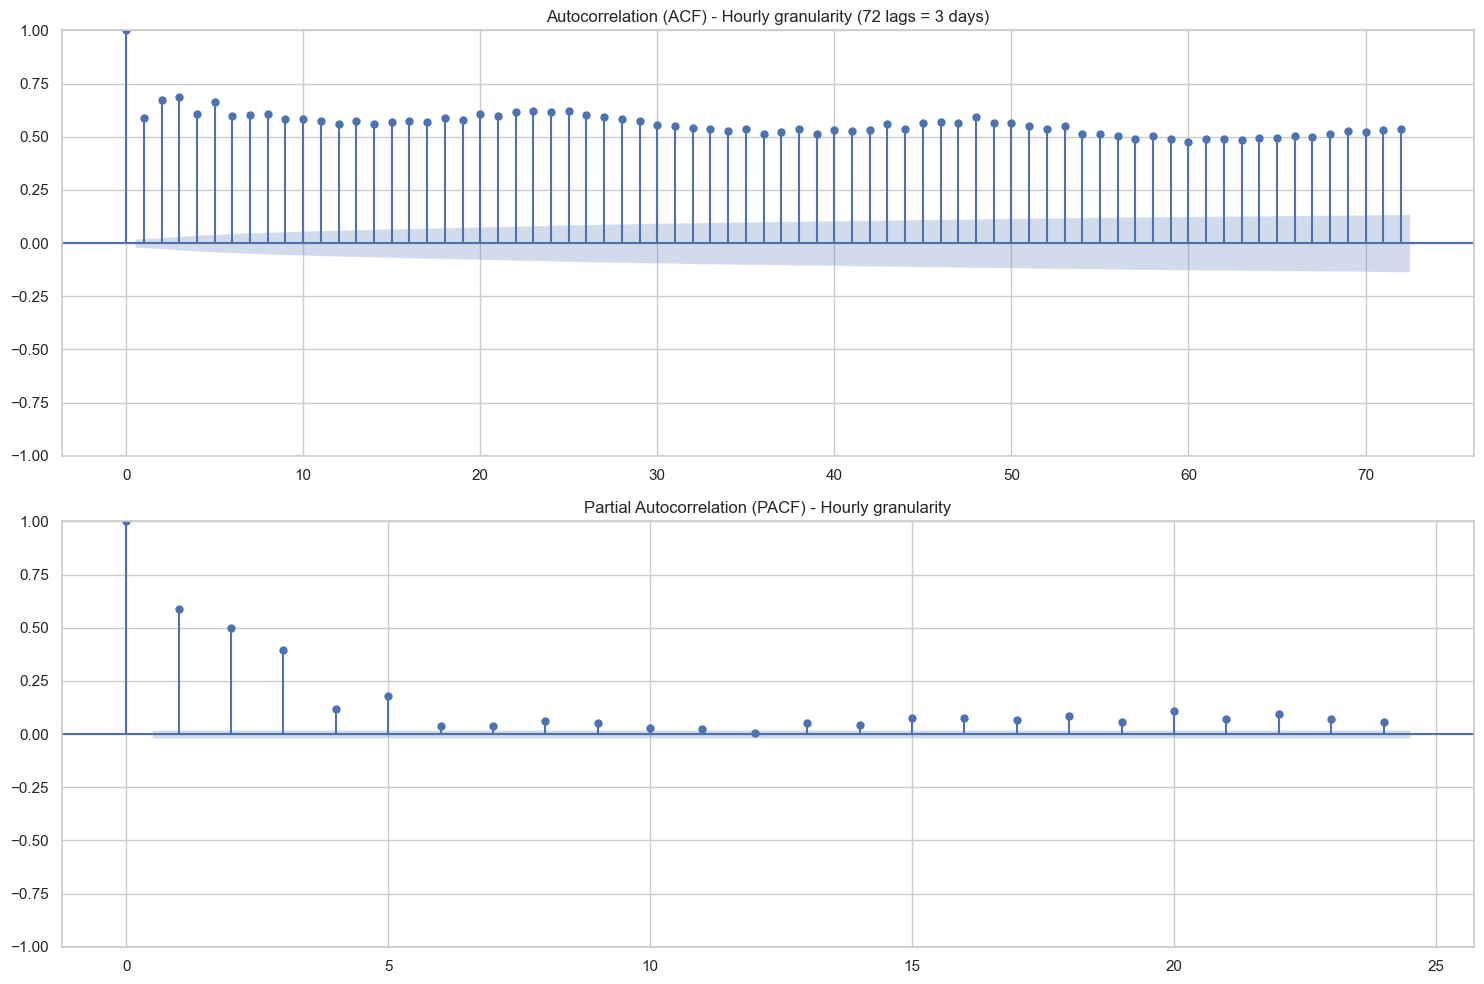

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

# Fill NaNs optionally created by resampling to avoid statsmodels errors
ts_x2 = dev1_hr['x2'].fillna(method='ffill').dropna()

# Check ACF for daily lag natively on hourly data (24 lags = 1 day)
plot_acf(ts_x2, lags=72, ax=axes[0], title="Autocorrelation (ACF) - Hourly granularity (72 lags = 3 days)")

# Check PACF
plot_pacf(ts_x2, lags=24, ax=axes[1], title="Partial Autocorrelation (PACF) - Hourly granularity")
plt.tight_layout()
plt.show()

## 5. Next Steps for Modeling
1. **Feature Engineering**: Creating lagged features, rolling means of `t1` (temperatures) and `x2`, time-based variables (hour of day, day of week).
2. **Aggregation**: The final submission expects Monthly predictions of average `x2`. We must predict out to May-Oct 2025.
3. **Model Selection**: LightGBM/XGBoost on tabular device data + generated lags, or Time Series native models (Prophet/NeuralForecast/N-HiTS).